# Varying Filled Probability: Results & Disparity Analysis
See README for more details

In [241]:
import json
import math
import sys
import os

In [242]:
proj_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(proj_root)

In [243]:
import warnings

warnings.filterwarnings("ignore")

In [244]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
# Setting up for experiments (don't change this cell -- default parameters shouldn't change)
from src.caries_20220319 import CariesV2
from src.tools.Experiment import Experiment
from src.tools.sample import Range, Values, Sample

from src.tools.DataDict import DataDict

In [246]:
parameters = {
        # Number of kids
        'agents': 2500,
        # Number of steps in the simulation
        'steps': 36,
        # Model will record every n-th step
        'record_steps': 1,
        # Random seed - can be set to None
        'seed': 17,
        # Main decay/filled/missing/sound parameters
        'person_decay_prob': 0.01356,
        'person_filling_prob': 0.00996,
        'sound_to_cavitated': 0.008994,
        'cavitated_to_missing': 0.00848,
        'person_decay_feedback': 0.25,
        # Fluoride parameters
        'fluoride_effect': 1.00,
        'fluoride_slope': 3.00,
        'fluoride_months_effective': 6.00,
        'person_preventive_fluoride': 1.00,
        'fluoride_scenario': 3.00,
        # High-risk Kid initialization parameters
        'init_caries_prevalence': 0.215311,
        'init_caries_prob': 0.16,
        'init_missing_prob': 0.00848,
        # Behavioral decay parameters
        'behavioral_decay': 2,
        'behavioral_feedback': 1,
        'disable_decay': 0,
    }

## Setting (hyper)parameters

In [247]:
experiment_name = 'final_run_filled_missing_2500agents_30reps'
num_agents = 2500

# Iterations per sample
num_iterations = 30 
num_jobs = 1 #changes number of parallel runs (cpu usage)

num_steps = 51 # number of samples (should maybe add external step-size function)

exp_parameters = parameters.copy()



# Change number of steps between recording
exp_parameters['record_steps'] = 36 # This means the model will record every 36 steps (only at the beginning/end)

# Change this for percentage of initial high risk
# exp_parameters['init_caries_prevalence'] = 1.00 # all high risk

# Setting behavioral decay to the old default
exp_parameters['behavioral_decay'] = -1 

# Changing fluoride settings
exp_parameters['fluoride_scenario'] = 2.00 
exp_parameters['person_preventive_fluoride'] = 0.1 # Talk about this value
exp_parameters['fluoride_effect'] = 0.1 # and this value

# Changing the number of agents (faster run-time)
exp_parameters['agents'] = num_agents

# Setting the random seed
exp_parameters['seed'] = None

# Setting up sample ranges
# num_samples = (num_steps**2) #change this number base on number of ranges (now only 2)
num_samples = (num_steps)
range_filling_prob = Range(vmin=0, vmax=0.2)
# range_missing_prob = Range(vmin=0, vmax=0.2)

exp_parameters['person_filling_prob'] = range_filling_prob
# exp_parameters['cavitated_to_missing'] = range_missing_prob
# exp_parameters['cavitated_to_missing'] =  0.0848

exp_samples = Sample(parameters=exp_parameters, n=num_steps)

## Running the experiment

In [248]:
from src.caries_20220319 import CariesV2
from src.tools.Experiment import Experiment
from src.tools.sample import Range, Values, Sample
# Don't run this cell unless doing an experiment (experiments can take a while)
#exp = Experiment(CariesV2, sample=exp_samples, iterations=num_iterations, record=True)
#results = exp.run(n_jobs=num_jobs)
#results.save(exp_name=experiment_name)

# Data Output Processing
Calculating the variables and metrics that we want to analyze.

Different samples ranges and experiment data need differing treatment.

In [249]:
# Import data -- make sure exp_name is correct (takes from model_output folder and latest exp_id -- see README)
data_filled_missing = DataDict().load(exp_name=experiment_name) # set exp_id=:int: for specific choice

# extracting the desired dataframe (see README section to understand multi-index)
# df = results.variables.Kid
df = data_filled_missing.variables.Kid 

# param_samples = results.parameters.sample
param_samples = data_filled_missing.parameters.sample #checking the parameter samples

Loading from directory model_output/final_run_filled_missing_2500agents_30reps_1/
Loading info.json - Successful
Loading parameters_constants.json - Successful
Loading parameters_log.json - Successful
Loading parameters_sample.csv - Successful
Loading reporters.csv - Successful
Loading variables_Kid.csv - Successful


In [250]:
# We are only looking at the last time step (t=36)
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']

In [251]:
sum_missing_per_sample_id = [missing_df.loc[id].sum() for id in range(num_samples)] 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = [filled_df.loc[id].sum() for id in range(num_samples)]

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = [caries_df.loc[id].sum() for id in range(num_samples)]

In [252]:
caries_df

sample_id  iteration  obj_id  t 
0          0          1       36    11
                      2       36     2
                      3       36     2
                      4       36     0
                      5       36     0
                                    ..
50         29         2496    36     0
                      2497    36     0
                      2498    36     0
                      2499    36     0
                      2500    36     0
Name: caries, Length: 3825000, dtype: int64

In [253]:
avg_missing = np.array([np.divide(s, num_iterations) for s in sum_missing_per_sample_id])
avg_filled = np.array([np.divide(s, num_iterations) for s in sum_filled_per_sample_id])
avg_caries = np.array([np.divide(s, num_iterations) for s in sum_caries_per_sample_id])

missing = np.divide(avg_missing, num_agents) 
filled = np.divide(avg_filled, num_agents)
caries = np.divide(avg_caries, num_agents)

total_caries = caries + missing + filled
metric = caries + 2*missing + 0.5*filled

# Organizing Data
Putting everything into DataFrames for ease of use with Matplotlib and Seaborn

In [254]:
labels = param_samples.loc[:num_steps-1, "person_filling_prob"]
labels = labels.round(3)

In [255]:
# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
df_line_missing_filled = pd.Series(missing, index=labels)
df_line_filled_filled = pd.Series(filled, index=labels)
df_line_caries_filled = pd.Series(caries, index=labels)
df_line_total_caries_filled = pd.Series(total_caries, index=labels)
# df_line_untreated_time_filled = pd.Series(avg_untreated_time, index=labels)
df_line_metric_filled = pd.Series(metric, index=labels)

# Grid of all plots

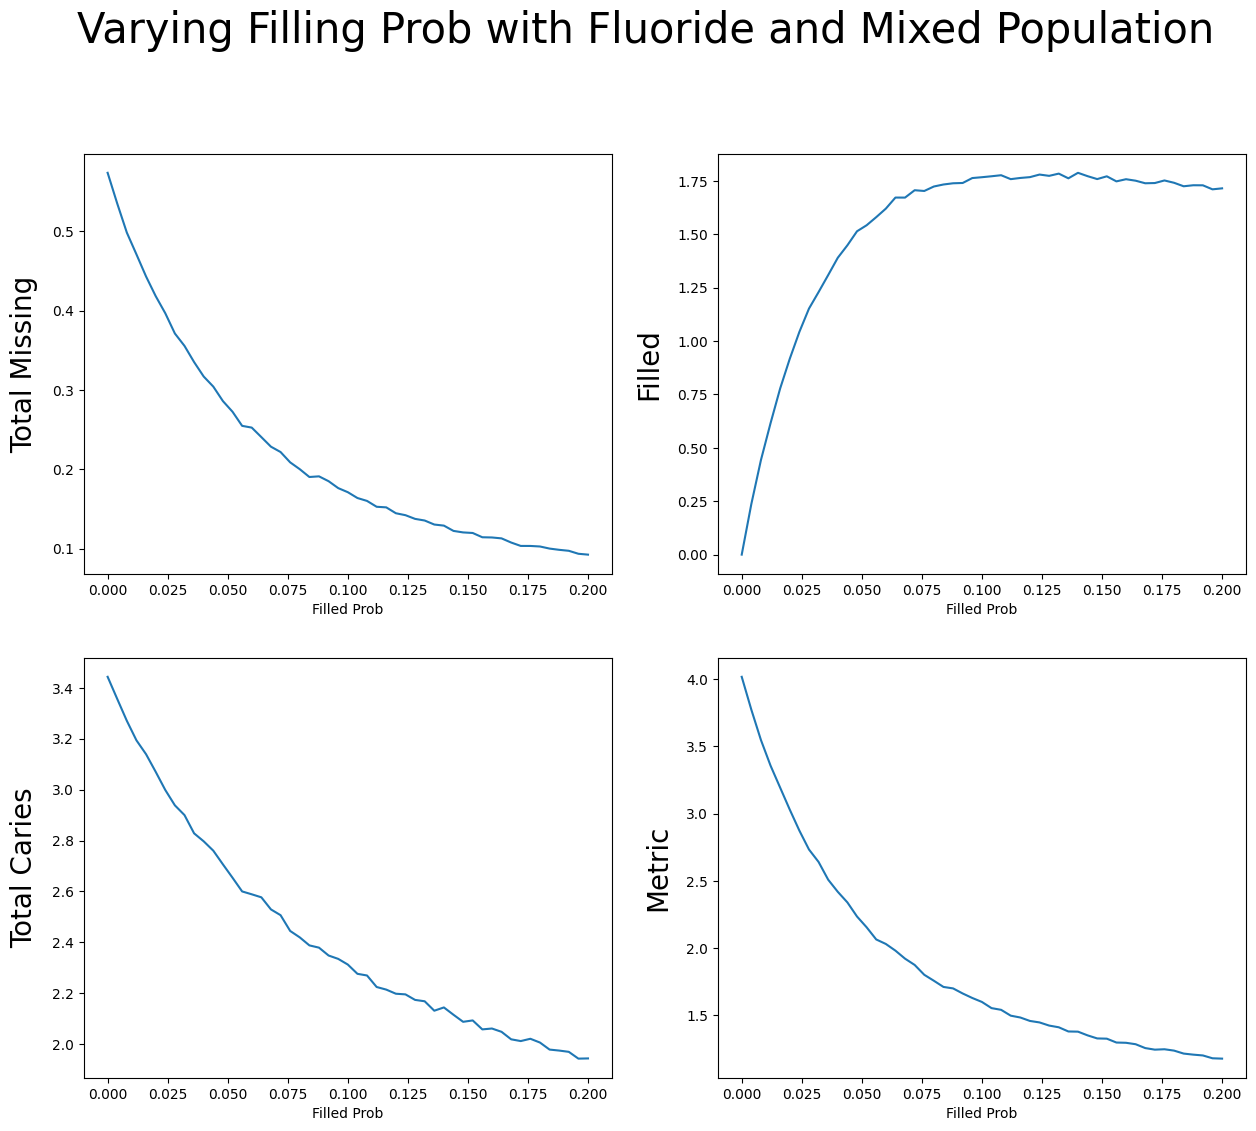

In [256]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Varying Filling Prob with Fluoride and Mixed Population", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Total Missing", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Filled", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Total Caries", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Metric", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].plot(df_line_missing_filled)
axs[0, 0].set_xlabel("Filled Prob")
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].plot(df_line_filled_filled)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].plot(df_line_total_caries_filled)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_caries_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].plot(df_line_metric_filled)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

In [257]:
df_line_missing_filled

person_filling_prob
0.000    0.573733
0.004    0.534987
0.008    0.498320
0.012    0.470893
0.016    0.443027
0.020    0.418307
0.024    0.396693
0.028    0.371120
0.032    0.355507
0.036    0.335093
0.040    0.316853
0.044    0.304147
0.048    0.285893
0.052    0.272453
0.056    0.254667
0.060    0.252467
0.064    0.240480
0.068    0.228400
0.072    0.221667
0.076    0.208640
0.080    0.200013
0.084    0.190187
0.088    0.191000
0.092    0.184880
0.096    0.176173
0.100    0.171013
0.104    0.163680
0.108    0.160013
0.112    0.152640
0.116    0.151893
0.120    0.144493
0.124    0.142027
0.128    0.137373
0.132    0.135307
0.136    0.130240
0.140    0.128880
0.144    0.122200
0.148    0.120307
0.152    0.119587
0.156    0.114200
0.160    0.113933
0.164    0.112787
0.168    0.107547
0.172    0.103267
0.176    0.103240
0.180    0.102560
0.184    0.099920
0.188    0.098360
0.192    0.097133
0.196    0.093373
0.200    0.092293
dtype: float64

# Untreated Decay Burden, Caries XP, and Disparity

In [258]:
num_Kids = exp_parameters['agents']
# --------------------------------------- #
#               Hi-Target                 #
# --------------------------------------- #
caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = [caries_df.loc[id].sum() for id in range(num_samples)]

caries_xp_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries_xp']
sum_caries_xp_per_sample_id = [caries_xp_df.loc[id].sum() for id in range(num_samples)]

lo_df = df.loc[df['high_risk'] == 0]

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_lo_caries_per_sample_id = [lo_caries_df.loc[id].sum() for id in range(num_samples)]

lo_caries_xp_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries_xp']
sum_lo_caries_xp_per_sample_id = np.divide(np.array([lo_caries_xp_df.loc[id].sum() for id in range(num_samples)]), num_iterations)

num_hi_Kids_df = df.loc[(slice(None), slice(None), slice(None), 36), 'high_risk']
num_hi_Kids_per_sample_id = np.divide(np.array([num_hi_Kids_df[id].sum() for id in range(num_samples)]), num_iterations)

num_lo_Kids_per_sample_id = np.full(num_samples, num_Kids) - num_hi_Kids_per_sample_id

In [259]:
num_hi_Kids_per_sample_id

array([536.66666667, 539.83333333, 536.66666667, 534.36666667,
       541.9       , 536.86666667, 536.76666667, 536.7       ,
       539.23333333, 530.13333333, 536.23333333, 540.2       ,
       535.53333333, 534.53333333, 532.53333333, 542.46666667,
       542.53333333, 543.56666667, 545.56666667, 536.1       ,
       536.36666667, 535.26666667, 541.1       , 532.13333333,
       537.7       , 538.1       , 536.56666667, 541.73333333,
       534.56666667, 536.2       , 537.26666667, 536.6       ,
       540.76666667, 543.83333333, 537.63333333, 544.53333333,
       541.06666667, 531.8       , 540.06666667, 534.1       ,
       540.1       , 535.93333333, 535.        , 534.4       ,
       540.8       , 539.56666667, 530.63333333, 536.76666667,
       537.13333333, 531.5       , 535.03333333])

In [260]:
num_Kids

2500

In [261]:
# --------------------------------------- #
#               Hi-Target                 #
# --------------------------------------- #
avg_caries = np.array([np.divide(s, num_iterations*xp) for (s, xp) in zip(sum_caries_per_sample_id,sum_caries_xp_per_sample_id)])
avg_caries_xp = np.array([np.divide(s, num_iterations*num_Kids) for s in sum_caries_xp_per_sample_id])

sum_lo_caries_per_iteration = np.array([np.divide(s, num_iterations) for s in sum_lo_caries_per_sample_id])
sum_caries_per_iteration = np.array([np.divide(s, num_iterations) for s in sum_caries_per_sample_id])

avg_lo_caries = np.divide(sum_lo_caries_per_iteration, num_lo_Kids_per_sample_id)
avg_hi_caries = np.divide(sum_caries_per_iteration-sum_lo_caries_per_iteration, num_hi_Kids_per_sample_id)

avg_lo_caries_xp = np.divide(sum_lo_caries_xp_per_sample_id, num_lo_Kids_per_sample_id)

caries = avg_caries
caries_xp = avg_caries_xp
caries_disparity = avg_hi_caries - avg_lo_caries
caries_xp_disparity = np.ones(num_steps) - avg_lo_caries_xp

In [262]:
# --------------------------------------- #
#               Hi-Target                 #
# --------------------------------------- #

df_plt_caries = pd.Series(caries, index=labels)
df_plt_caries_xp = pd.Series(caries_xp, index=labels)

df_plt_caries_disparity = pd.Series(caries_disparity, index=labels)
df_plt_caries_xp_disparity = pd.Series(caries_xp_disparity, index=labels)

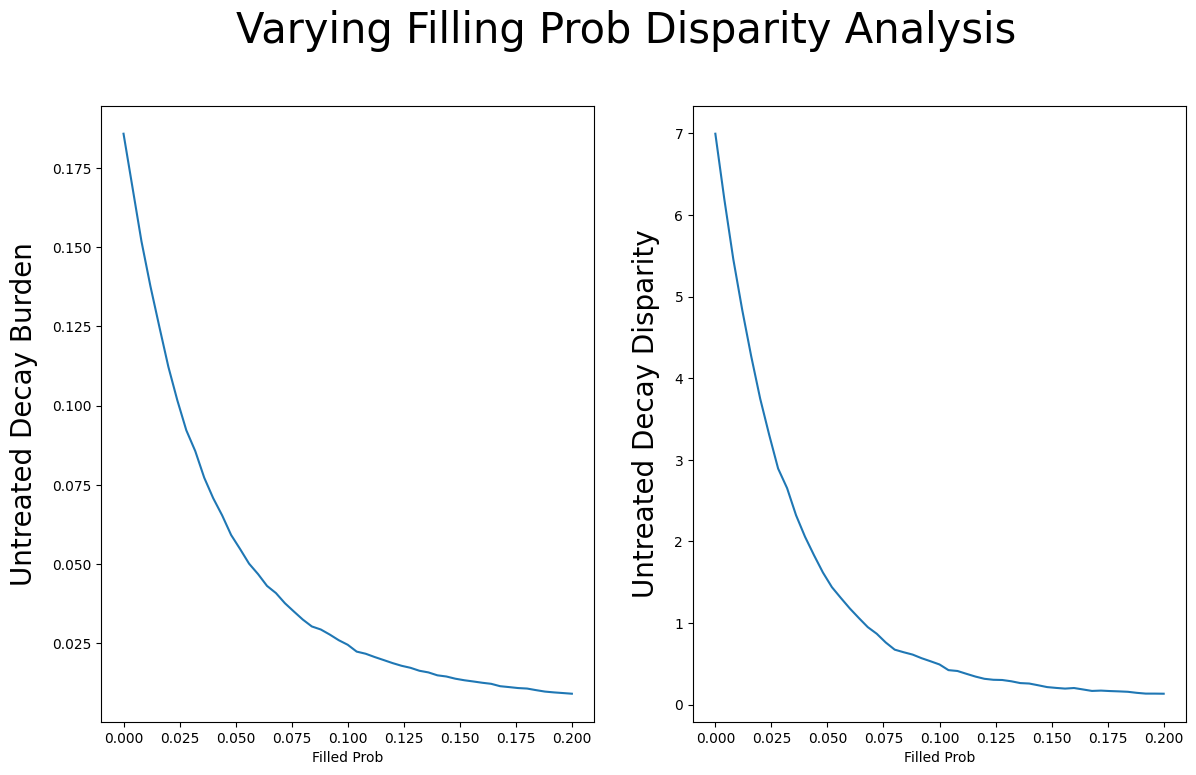

In [263]:
fig, axs = plt.subplots(1, 2)
fig.suptitle("Varying Filling Prob Disparity Analysis", fontsize=30, y=1, weight=500)
fig.set_size_inches(14, 8)
fig.set_dpi(100)


axs[0].set_ylabel("Untreated Decay Burden", fontsize=20, labelpad=10)
axs[1].set_ylabel("Untreated Decay Disparity", fontsize=20, labelpad=10)
# axs[1, 0].set_ylabel("Avg Caries XP", fontsize=20, labelpad=10)
# axs[1, 1].set_ylabel("Caries XP Disparity", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0].plot(df_plt_caries)
axs[0].set_xlabel("Filled Prob")

axs[1].plot(df_plt_caries_disparity)
axs[1].set_xlabel("Filled Prob")

# axs[1, 0].plot(df_plt_caries_xp)
# axs[1, 0].set_xlabel("Filled Prob")

# axs[1, 1].plot(df_plt_caries_xp_disparity)
# axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

# Average Time to Treatment

In [264]:
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_missing_per_sample_id = np.array([missing_df.loc[id].sum() for id in range(num_samples)]) 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = np.array([filled_df.loc[id].sum() for id in range(num_samples)])

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = np.array([caries_df.loc[id].sum() for id in range(num_samples)])

In [265]:
lo_missing_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_lo_missing_per_sample_id = np.array([lo_missing_df.loc[id].sum() for id in range(num_samples)]) 

lo_filled_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_lo_filled_per_sample_id = np.array([lo_filled_df.loc[id].sum() for id in range(num_samples)])

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_lo_caries_per_sample_id = np.array([lo_caries_df.loc[id].sum() for id in range(num_samples)])

In [266]:
total_caries_per_sample_id = sum_caries_per_sample_id + sum_filled_per_sample_id + sum_missing_per_sample_id
total_lo_caries_per_sample_id = sum_lo_caries_per_sample_id + sum_lo_filled_per_sample_id + sum_lo_missing_per_sample_id
total_hi_caries_per_sample_id = total_caries_per_sample_id - total_lo_caries_per_sample_id

untreated_time_df = df.loc[(slice(None), slice(None), slice(None), 36), 'untreated_time']
sum_untreated_time_per_sample_id = np.array([untreated_time_df.loc[id].sum() for id in range(num_samples)])

# untreated_time = np.array([np.divide(s, num_iterations) for s in sum_untreated_time_per_sample_id])
avg_untreated_time = np.divide(sum_untreated_time_per_sample_id, num_iterations * total_caries_per_sample_id)
# avg_untreated_time = np.divide(untreated_time, avg_missing + avg_filled + avg_caries)


lo_untreated_time_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'untreated_time']
sum_lo_untreated_time_per_sample_id = np.array([lo_untreated_time_df.loc[id].sum() for id in range(num_samples)])
sum_hi_untreated_time_per_sample_id = sum_untreated_time_per_sample_id - sum_lo_untreated_time_per_sample_id

avg_lo_untreated_time = np.divide(sum_lo_untreated_time_per_sample_id, num_iterations * total_lo_caries_per_sample_id)
avg_hi_untreated_time = np.divide(sum_hi_untreated_time_per_sample_id, num_iterations * total_hi_caries_per_sample_id)
untreated_time_disparity = avg_hi_untreated_time - avg_lo_untreated_time

df_untreated_time = pd.Series(avg_untreated_time, index=labels)
df_untreated_time_disparity = pd.Series(untreated_time_disparity, index=labels)

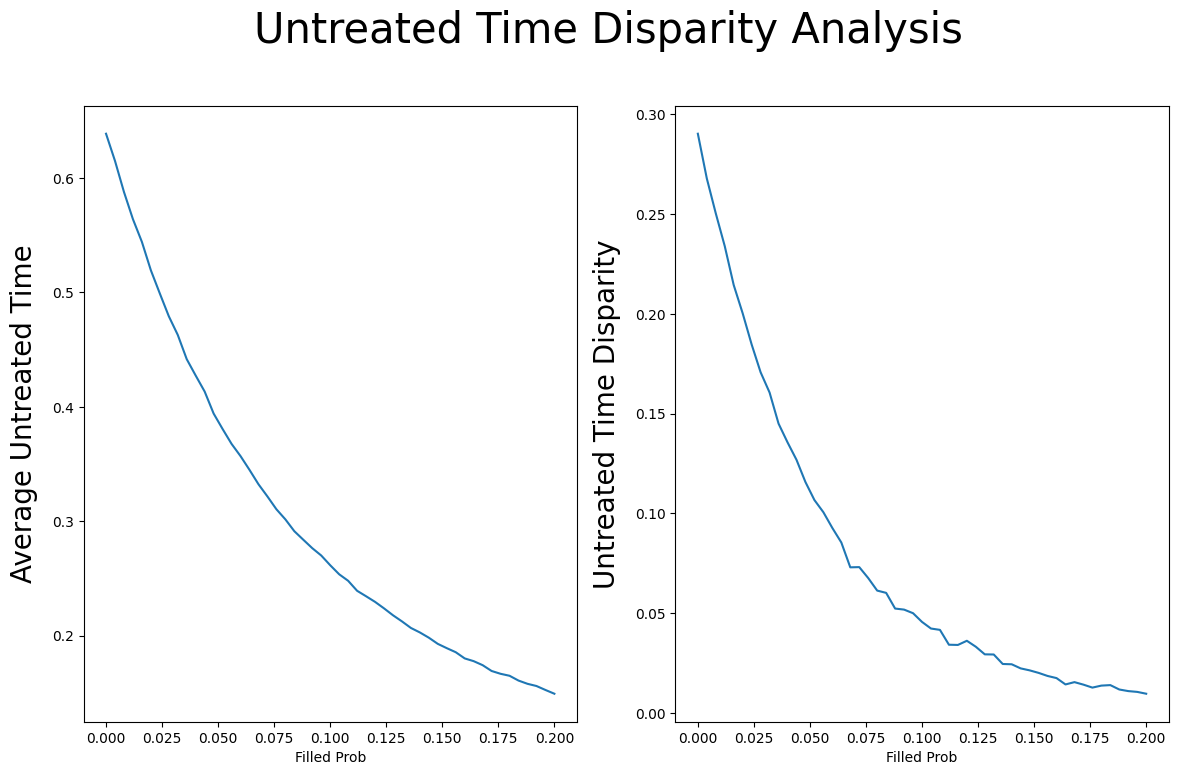

In [267]:
fig, axs = plt.subplots(1, 2)
fig.suptitle("Untreated Time Disparity Analysis", fontsize=30, y=1, weight=500)
fig.set_size_inches(14, 8)
fig.set_dpi(100)


axs[0].set_ylabel("Average Untreated Time", fontsize=20, labelpad=10)
axs[1].set_ylabel("Untreated Time Disparity", fontsize=20, labelpad=10)
# axs[1, 0].set_ylabel("Avg Caries XP", fontsize=20, labelpad=10)
# axs[1, 1].set_ylabel("Caries XP Disparity", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0].plot(df_untreated_time)
axs[0].set_xlabel("Filled Prob")

axs[1].plot(df_untreated_time_disparity)
axs[1].set_xlabel("Filled Prob")

# axs[1, 0].plot(df_plt_caries_xp)
# axs[1, 0].set_xlabel("Filled Prob")

# axs[1, 1].plot(df_plt_caries_xp_disparity)
# axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

# Other Disparities

In [268]:
missing_df = df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_missing_per_sample_id = np.array([missing_df.loc[id].sum() for id in range(num_samples)]) 

filled_df = df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_filled_per_sample_id = np.array([filled_df.loc[id].sum() for id in range(num_samples)])

caries_df = df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_caries_per_sample_id = np.array([caries_df.loc[id].sum() for id in range(num_samples)])

In [269]:
lo_missing_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'missing']
sum_lo_missing_per_sample_id = np.array([lo_missing_df.loc[id].sum() for id in range(num_samples)]) 

lo_filled_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'filled']
sum_lo_filled_per_sample_id = np.array([lo_filled_df.loc[id].sum() for id in range(num_samples)])

lo_caries_df = lo_df.loc[(slice(None), slice(None), slice(None), 36), 'caries']
sum_lo_caries_per_sample_id = np.array([lo_caries_df.loc[id].sum() for id in range(num_samples)])

In [270]:
sum_hi_missing_per_sample_id = sum_missing_per_sample_id - sum_lo_missing_per_sample_id

sum_hi_filled_per_sample_id = sum_filled_per_sample_id - sum_lo_filled_per_sample_id

sum_hi_caries_per_sample_id = sum_caries_per_sample_id - sum_lo_caries_per_sample_id

In [271]:
missing_disparity_per_sample_id = sum_hi_missing_per_sample_id - sum_lo_missing_per_sample_id

filled_disparity_per_sample_id = sum_hi_filled_per_sample_id - sum_lo_filled_per_sample_id

caries_disparity_per_sample_id = sum_hi_caries_per_sample_id - sum_lo_caries_per_sample_id

In [272]:
missing_disparity = np.divide(missing_disparity_per_sample_id, num_agents* num_iterations) 
filled_disparity = np.divide(filled_disparity_per_sample_id, num_agents* num_iterations)
caries_disparity = np.divide(caries_disparity_per_sample_id, num_agents* num_iterations)
# missing_disparity = missing_disparity_per_sample_id
# filled_disparity = filled_disparity_per_sample_id
# caries_disparity = caries_disparity_per_sample_id

total_caries_disparity = missing_disparity + filled_disparity + caries_disparity
metric_disparity = caries_disparity + 2*missing_disparity + 0.5*filled_disparity

In [273]:
df_line_missing_disparity = pd.Series(missing_disparity, index=labels)
df_line_filled_disparity = pd.Series(filled_disparity, index=labels)
df_line_total_caries_disparity = pd.Series(total_caries_disparity, index=labels)
df_line_metric_disparity = pd.Series(metric_disparity, index=labels)

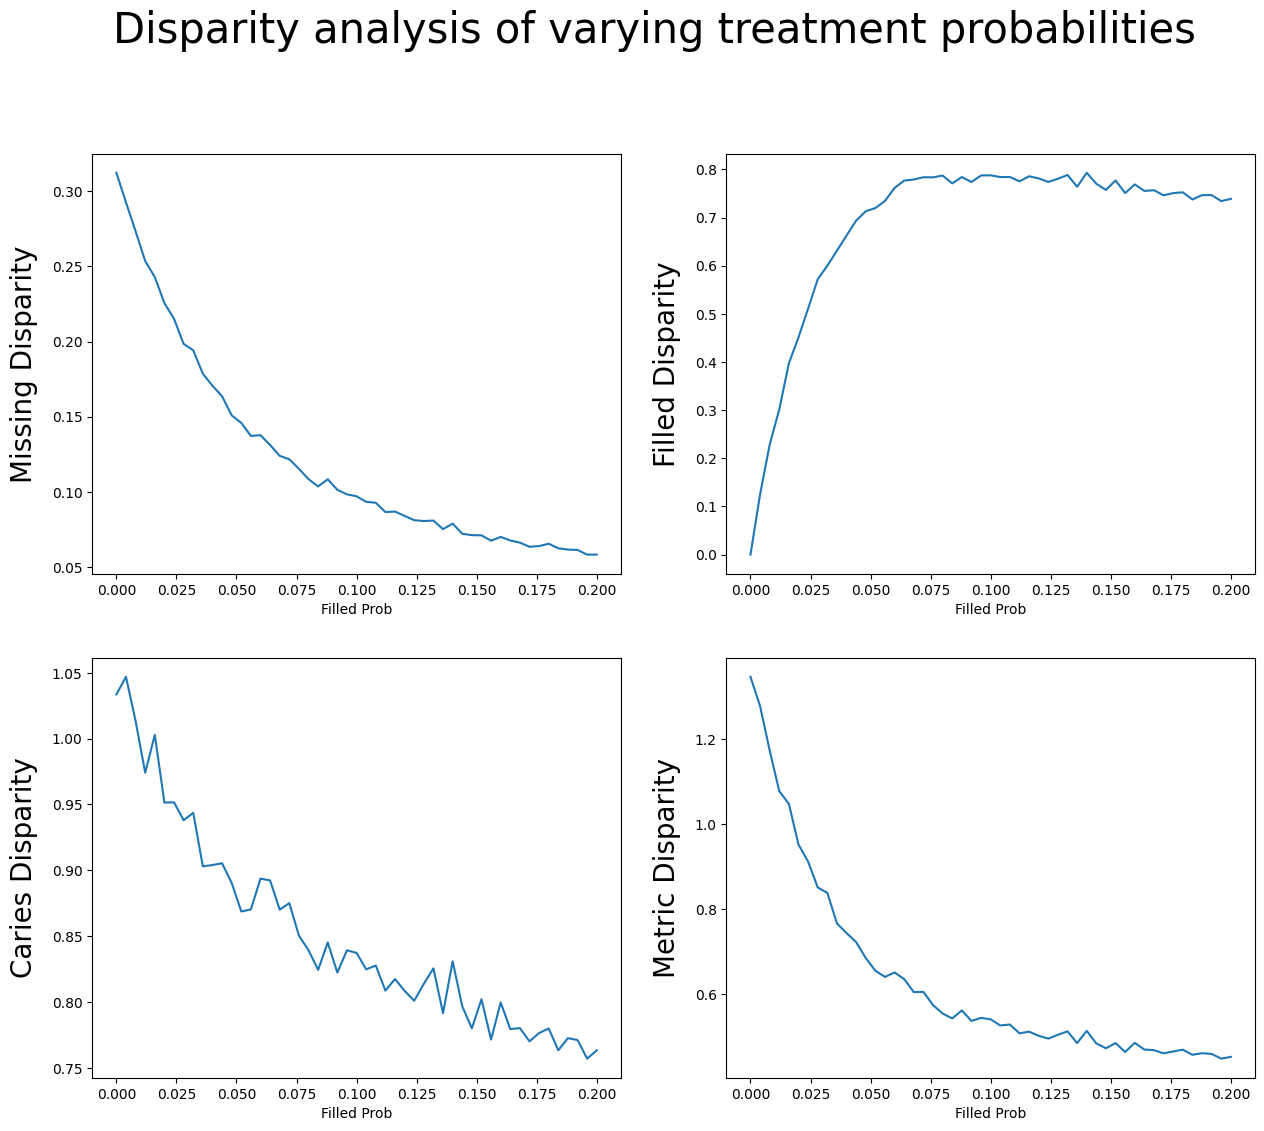

In [274]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Disparity analysis of varying treatment probabilities", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Missing Disparity", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Filled Disparity", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Caries Disparity", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Metric Disparity", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].plot(df_line_missing_disparity)
axs[0, 0].set_xlabel("Filled Prob")
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].plot(df_line_filled_disparity)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].plot(df_line_total_caries_disparity)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_untreated_time_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].plot(df_line_metric_disparity)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

In [275]:
missing_lo = np.divide(sum_lo_missing_per_sample_id, num_lo_Kids_per_sample_id * num_iterations) 
filled_lo = np.divide(sum_lo_filled_per_sample_id, num_lo_Kids_per_sample_id * num_iterations)
caries_lo = np.divide(sum_lo_caries_per_sample_id, num_lo_Kids_per_sample_id * num_iterations)


total_caries_lo = missing_lo + filled_lo + caries_lo
metric_lo = caries_lo + 2*missing_lo + 0.5*filled_lo

missing_hi = np.divide(sum_hi_missing_per_sample_id, num_hi_Kids_per_sample_id * num_iterations) 
filled_hi = np.divide(sum_hi_filled_per_sample_id, num_hi_Kids_per_sample_id * num_iterations)
caries_hi = np.divide(sum_hi_caries_per_sample_id, num_hi_Kids_per_sample_id * num_iterations) # * num_iterations ?


total_caries_hi = missing_hi + filled_hi + caries_hi
metric_hi = caries_hi + 2*missing_hi + 0.5*filled_hi

In [276]:
missing_lo

array([0.16645161, 0.15456169, 0.14320883, 0.13817429, 0.12777693,
       0.12272897, 0.1156086 , 0.10995093, 0.10286793, 0.0993299 ,
       0.09306944, 0.08966901, 0.08592663, 0.08052371, 0.07463066,
       0.07330654, 0.06981813, 0.06677117, 0.06397421, 0.0594056 ,
       0.05831028, 0.05510502, 0.05275069, 0.05308625, 0.04960166,
       0.04714817, 0.04480247, 0.04296316, 0.04206028, 0.04139933,
       0.03856866, 0.03879325, 0.03625568, 0.03479594, 0.03511067,
       0.03199577, 0.03200721, 0.03122989, 0.03098745, 0.02972345,
       0.02802864, 0.02876684, 0.02631043, 0.02535273, 0.02511229,
       0.02368524, 0.02381476, 0.02344771, 0.02282376, 0.02235204,
       0.02167976])

In [277]:
df_line_missing_lo = pd.Series(missing_lo, index=labels)
df_line_filled_lo = pd.Series(filled_lo, index=labels)
df_line_caries_lo = pd.Series(caries_lo, index=labels)
df_line_total_caries_lo = pd.Series(total_caries_lo, index=labels)
df_line_metric_lo = pd.Series(metric_lo, index=labels)

df_line_missing_hi = pd.Series(missing_hi, index=labels)
df_line_filled_hi = pd.Series(filled_hi, index=labels)
df_line_caries_hi = pd.Series(caries_hi, index=labels)
df_line_total_caries_hi = pd.Series(total_caries_hi, index=labels)
df_line_metric_hi = pd.Series(metric_hi, index=labels)

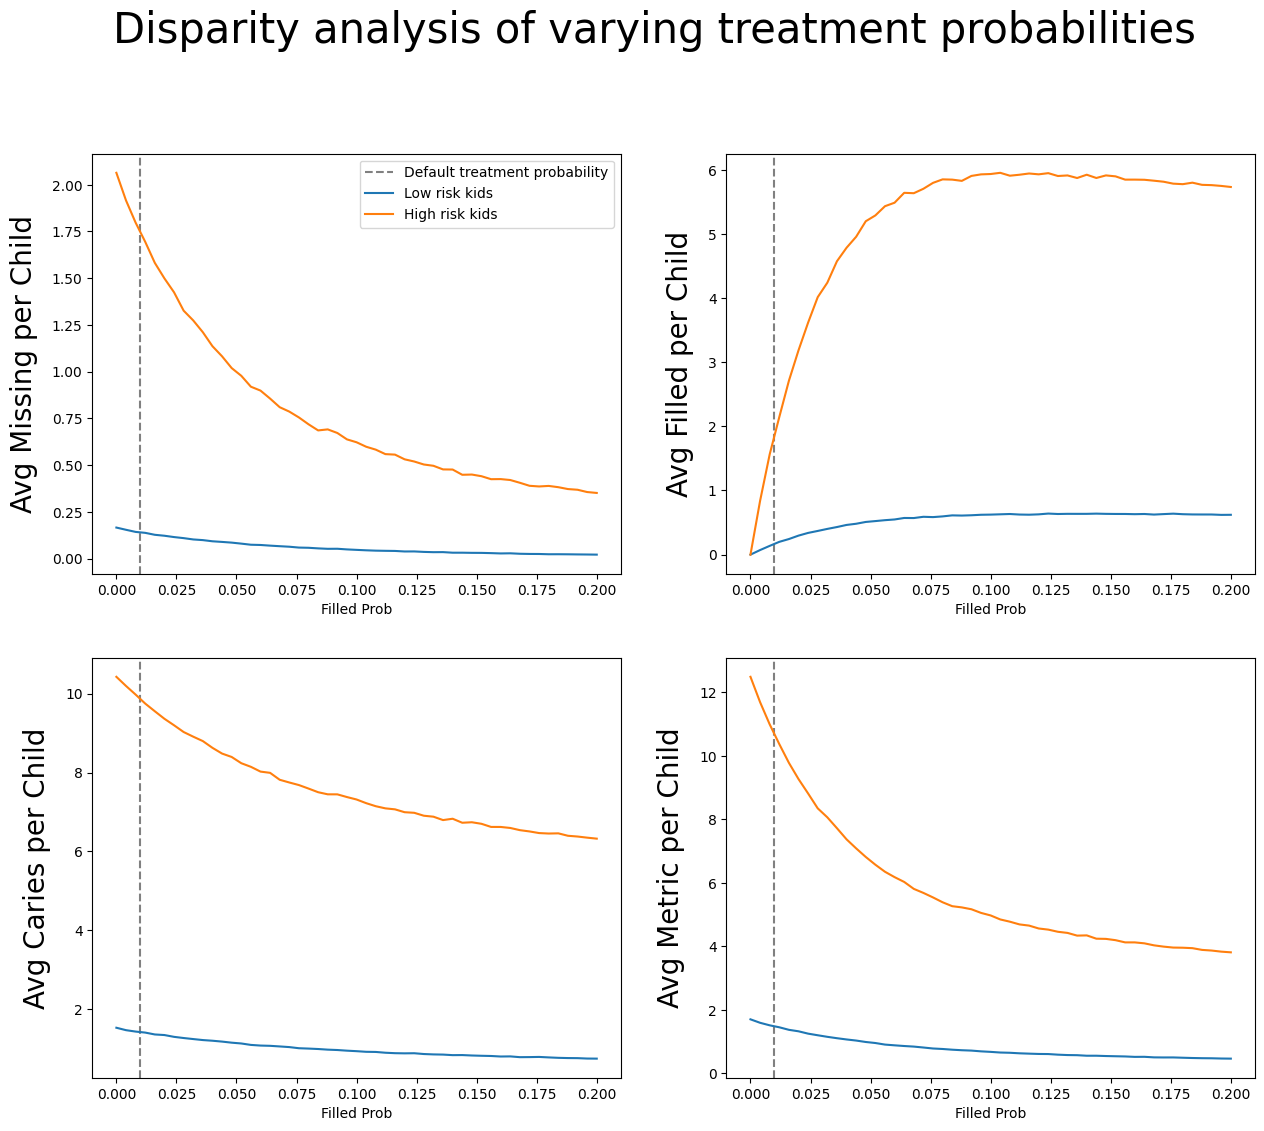

In [278]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Disparity analysis of varying treatment probabilities", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Avg Missing per Child", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Avg Filled per Child", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Avg Caries per Child", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Avg Metric per Child", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[0, 0].plot(df_line_missing_lo, label='Low risk kids')
axs[0, 0].plot(df_line_missing_hi, label='High risk kids')
axs[0, 0].set_xlabel("Filled Prob")
axs[0, 0].legend()
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[0, 1].plot(df_line_filled_lo)
axs[0, 1].plot(df_line_filled_hi)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[1, 0].plot(df_line_total_caries_lo)
axs[1, 0].plot(df_line_total_caries_hi)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_untreated_time_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[1, 1].plot(df_line_metric_lo)
axs[1, 1].plot(df_line_metric_hi)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

In [279]:
df_line_missing_lo_fixed = pd.Series([missing_lo[2] for _ in missing_lo], index=labels)
df_line_filled_lo_fixed = pd.Series([filled_lo[2] for _ in filled_lo], index=labels)
df_line_total_caries_lo_fixed = pd.Series([total_caries_lo[2] for _ in total_caries_lo], index=labels)
df_line_metric_lo_fixed = pd.Series([metric_lo[2] for _ in metric_lo], index=labels)

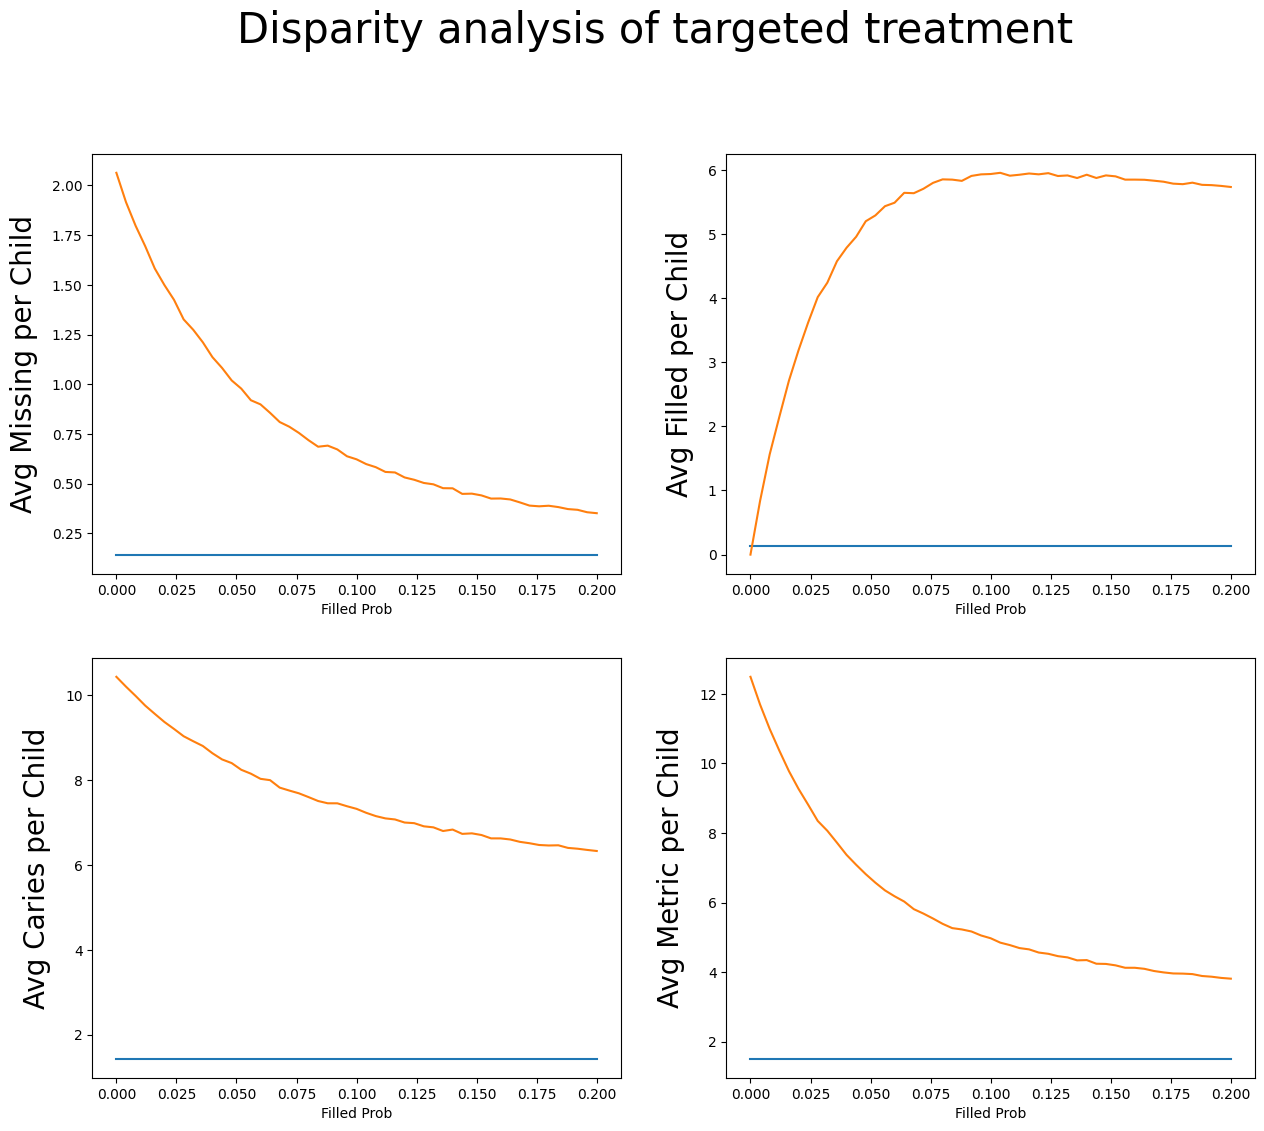

In [280]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("Disparity analysis of targeted treatment", fontsize=30, y=1, weight=500)
fig.set_size_inches(15, 12)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Avg Missing per Child", fontsize=20, labelpad=10)
axs[0, 1].set_ylabel("Avg Filled per Child", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Avg Caries per Child", fontsize=20, labelpad=10)
# axs[3].set_ylabel("Untreated Time", fontsize=20, labelpad=10)
axs[1, 1].set_ylabel("Avg Metric per Child", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].plot(df_line_missing_lo_fixed)
axs[0, 0].plot(df_line_missing_hi)
axs[0, 0].set_xlabel("Filled Prob")
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].plot(df_line_filled_lo_fixed)
axs[0, 1].plot(df_line_filled_hi)
axs[0, 1].set_xlabel("Filled Prob")

axs[1, 0].plot(df_line_total_caries_lo_fixed)
axs[1, 0].plot(df_line_total_caries_hi)
axs[1, 0].set_xlabel("Filled Prob")

# axs[3].plot(df_line_untreated_time_filled)
# axs[3].set_xlabel("Filled Prob")

axs[1, 1].plot(df_line_metric_lo_fixed)
axs[1, 1].plot(df_line_metric_hi)
axs[1, 1].set_xlabel("Filled Prob")

# fig.tight_layout()
plt.show()

# Full disparity graphs

In [291]:
# --------------------------------------- #
#             Disparities                 #
# --------------------------------------- #

df_line_missing_disp = pd.Series(missing_hi - missing_lo, index=labels)
df_line_filled_disp = pd.Series(filled_hi - filled_lo, index=labels)
df_line_caries_disp = pd.Series(caries_hi - caries_lo, index=labels)
df_line_total_caries_disp = pd.Series(total_caries_hi - total_caries_lo, index=labels)
df_line_metric_disp = pd.Series(metric_hi - metric_lo, index=labels)

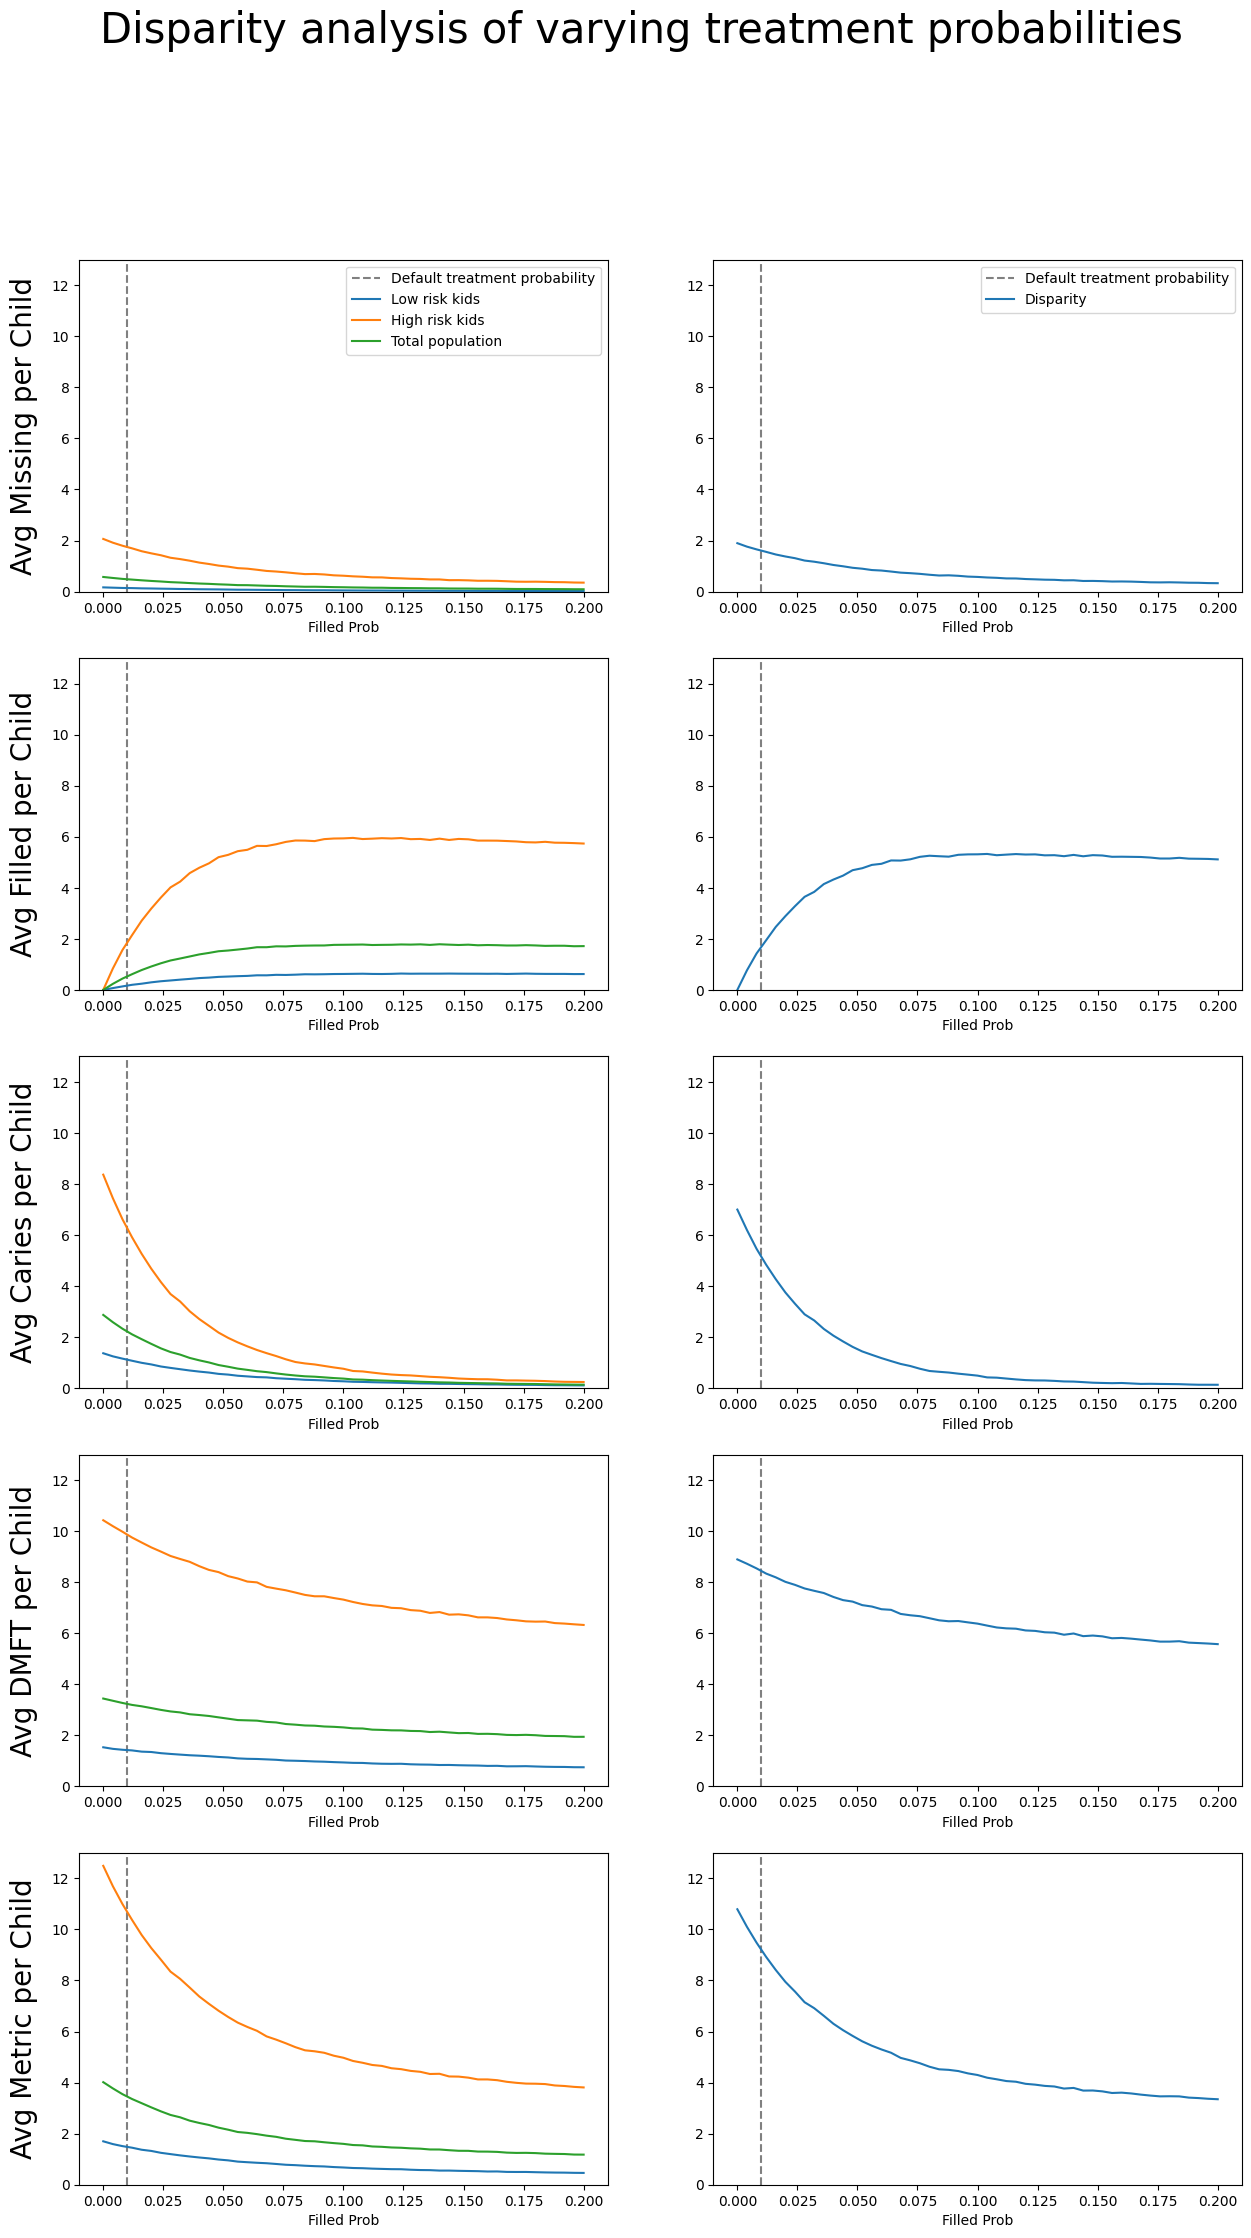

In [294]:
fig, axs = plt.subplots(5, 2)
fig.suptitle("Disparity analysis of varying treatment probabilities", fontsize=30, weight=500)
fig.set_size_inches(15, 25)
fig.set_dpi(100)


# --------------------------------------- #
#                Labels                   #
# --------------------------------------- #

axs[0, 0].set_ylabel("Avg Missing per Child", fontsize=20, labelpad=10)
axs[1, 0].set_ylabel("Avg Filled per Child", fontsize=20, labelpad=10)
axs[2, 0].set_ylabel("Avg Caries per Child", fontsize=20, labelpad=10)
axs[3, 0].set_ylabel("Avg DMFT per Child", fontsize=20, labelpad=10)
axs[4, 0].set_ylabel("Avg Metric per Child", fontsize=20, labelpad=10)


# --------------------------------------- #
#          Filled Line Graphs             #
# --------------------------------------- #
axs[0, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[0, 0].plot(df_line_missing_lo, label='Low risk kids')
axs[0, 0].plot(df_line_missing_hi, label='High risk kids')
axs[0, 0].plot(df_line_missing_filled, label='Total population')
axs[0, 0].set_xlabel("Filled Prob")
axs[0, 0].legend()
# axs[0].set_title("Missing Probability = 0.008", fontsize=20, y=1.08)

axs[0, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[0, 1].plot(df_line_missing_disp, label='Disparity')
axs[0, 1].set_xlabel("Filled Prob")
axs[0, 1].legend()

axs[1, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[1, 0].plot(df_line_filled_lo)
axs[1, 0].plot(df_line_filled_hi)
axs[1, 0].plot(df_line_filled_filled)
axs[1, 0].set_xlabel("Filled Prob")

axs[1, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[1, 1].plot(df_line_filled_disp)
axs[1, 1].set_xlabel("Filled Prob")

axs[2, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[2, 0].plot(df_line_caries_lo)
axs[2, 0].plot(df_line_caries_hi)
axs[2, 0].plot(df_line_caries_filled)
axs[2, 0].set_xlabel("Filled Prob")

axs[2, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[2, 1].plot(df_line_caries_disp)
axs[2, 1].set_xlabel("Filled Prob")

axs[3, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[3, 0].plot(df_line_total_caries_lo)
axs[3, 0].plot(df_line_total_caries_hi)
axs[3, 0].plot(df_line_total_caries_filled)
axs[3, 0].set_xlabel("Filled Prob")

axs[3, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[3, 1].plot(df_line_total_caries_disp)
axs[3, 1].set_xlabel("Filled Prob")

axs[4, 0].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed')
axs[4, 0].plot(df_line_metric_lo)
axs[4, 0].plot(df_line_metric_hi)
axs[4, 0].plot(df_line_metric_filled)
axs[4, 0].set_xlabel("Filled Prob")

axs[4, 1].axvline(x=parameters['person_filling_prob'], color='grey', linestyle='dashed', label='Default treatment probability')
axs[4, 1].plot(df_line_metric_disp)
axs[4, 1].set_xlabel("Filled Prob")

for ax_row in axs:
    for ax in ax_row:
        ax.set_ylim(0, 13)


# fig.tight_layout()
plt.show()